# MIDI → Audio Synthesis with a U-Net + HiFi-GAN
**Task 4 — Continuous Conditioned Generation**

Pipeline:
1. Download a subset of the MAESTRO dataset (paired MIDI + audio)
2. Pre-process: extract piano rolls from MIDI, mel spectrograms from audio
3. Train a U-Net to predict mel spectrograms from piano rolls
4. Convert predicted spectrograms to audio with a pretrained HiFi-GAN vocoder
5. Evaluate with spectral loss, mel cepstral distortion, and listening examples

> **Runtime**: GPU required. Use *Runtime → Change runtime type → T4 GPU* in Colab.


## 1. Install & import dependencies

In [1]:
# Install dependencies (run once)
!pip install pretty_midi librosa soundfile torch torchvision torchaudio --quiet
!pip install matplotlib numpy scipy tqdm --quiet

# HiFi-GAN vocoder (official repo)
import os
if not os.path.exists("hifi-gan"):
    !git clone https://github.com/jik876/hifi-gan.git --quiet



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys, json, math, random, time, urllib.request, zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pretty_midi
import soundfile as sf
from scipy.io import wavfile
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## 2. Configuration

In [12]:
# ── Audio / spectrogram settings ──────────────────────────────────────────────
SR          = 22050       # sample rate (Hz)
HOP_LENGTH  = 256         # STFT hop
WIN_LENGTH  = 1024        # STFT window
N_FFT       = 1024
N_MELS      = 128         # mel bins
FMIN        = 20.0
FMAX        = 8000.0

# ── Piano roll settings ───────────────────────────────────────────────────────
PIANO_MIN   = 21          # MIDI note A0
PIANO_MAX   = 108         # MIDI note C8
N_NOTES     = PIANO_MAX - PIANO_MIN + 1   # 88 keys

# ── Clip settings ─────────────────────────────────────────────────────────────
CLIP_SECONDS = 4.0        # seconds per training clip
CLIP_FRAMES  = int(SR * CLIP_SECONDS / HOP_LENGTH)   # time frames per clip

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 4
EPOCHS       = 30
LR           = 1e-4
TRAIN_SPLIT  = 0.85

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("maestro_mini/maestro-v3.0.0")
CKPT_DIR    = Path("checkpoints")
OUT_DIR     = Path("outputs")
for d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(exist_ok=True)

print("Config loaded.")
print(f"  Clip frames : {CLIP_FRAMES}")
print(f"  Piano keys  : {N_NOTES}")
print(f"  Mel bins    : {N_MELS}")


Config loaded.
  Clip frames : 344
  Piano keys  : 88
  Mel bins    : 128


## 3. Data — MAESTRO mini subset

We download **MAESTRO v3.0.0** metadata CSV and then fetch a small balanced
subset of MIDI + audio pairs (≈ 2 GB total for ~50 tracks). If you have more
disk space and time, increase `MAX_FILES`.


In [4]:
import csv, shutil

MAESTRO_BASE = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0"
META_URL     = f"{MAESTRO_BASE}/maestro-v3.0.0.csv"
MAX_FILES    = 200   # increase for better results (each file ~40 MB audio)

meta_path = DATA_DIR / "maestro-v3.0.0.csv"
if not meta_path.exists():
    print("Downloading metadata CSV …")
    urllib.request.urlretrieve(META_URL, meta_path)
    print("Done.")

# Parse CSV
records = []
with open(meta_path, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        records.append(row)

print(f"Total tracks in MAESTRO: {len(records)}")

# Grab a balanced sample across splits
train_recs = [r for r in records if r["split"] == "train"][:MAX_FILES]
val_recs   = [r for r in records if r["split"] == "validation"][:max(4, MAX_FILES//10)]
use_recs   = train_recs + val_recs
print(f"Using {len(use_recs)} tracks ({len(train_recs)} train, {len(val_recs)} val)")


Total tracks in MAESTRO: 1276
Using 220 tracks (200 train, 20 val)


In [5]:
def download_file(url, dest: Path):
    if dest.exists():
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dest)

failed = []
for rec in tqdm(use_recs, desc="Downloading MAESTRO files"):
    year = rec["audio_filename"].split("/")[0]
    for key in ["audio_filename", "midi_filename"]:
        fname = rec[key]
        url   = f"{MAESTRO_BASE}/{fname}"
        dest  = DATA_DIR / fname
        try:
            download_file(url, dest)
        except Exception as e:
            failed.append((fname, str(e)))

if failed:
    print(f"⚠️  {len(failed)} files failed to download:")
    for f, e in failed[:5]:
        print(f"  {f}: {e}")
else:
    print("All files downloaded successfully.")


All files downloaded successfully.


## 4. Exploratory Data Analysis

Before training, we inspect the dataset: duration distribution, pitch density,
and example piano roll + spectrogram pairs.


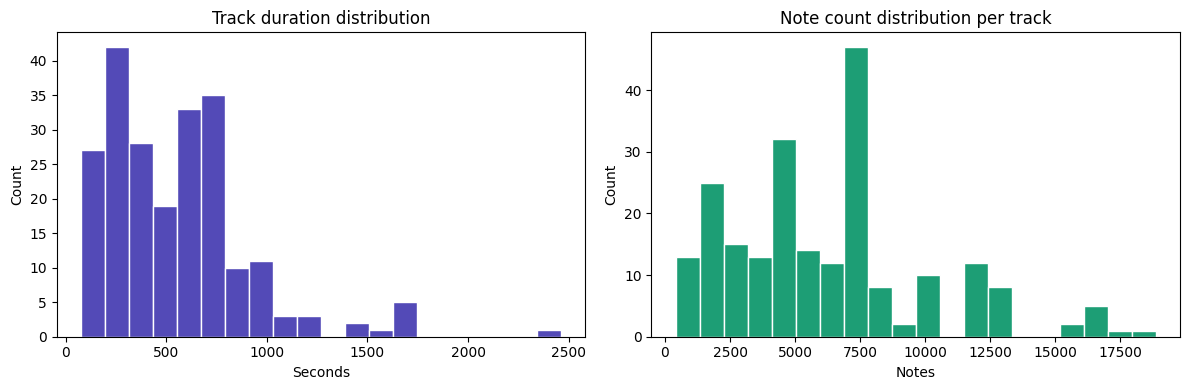

Duration — mean: 555.6s  median: 509.8s
Notes    — mean: 6226  median: 5761


In [6]:
# Collect metadata stats
durations, note_counts = [], []
for rec in use_recs:
    midi_path = DATA_DIR / rec["midi_filename"]
    if not midi_path.exists():
        continue
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        durations.append(pm.get_end_time())
        note_counts.append(sum(len(inst.notes) for inst in pm.instruments))
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(durations, bins=20, color="#534AB7", edgecolor="white")
axes[0].set_title("Track duration distribution")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Count")

axes[1].hist(note_counts, bins=20, color="#1D9E75", edgecolor="white")
axes[1].set_title("Note count distribution per track")
axes[1].set_xlabel("Notes")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_distributions.png", dpi=120)
plt.show()

print(f"Duration — mean: {np.mean(durations):.1f}s  median: {np.median(durations):.1f}s")
print(f"Notes    — mean: {np.mean(note_counts):.0f}  median: {np.median(note_counts):.0f}")


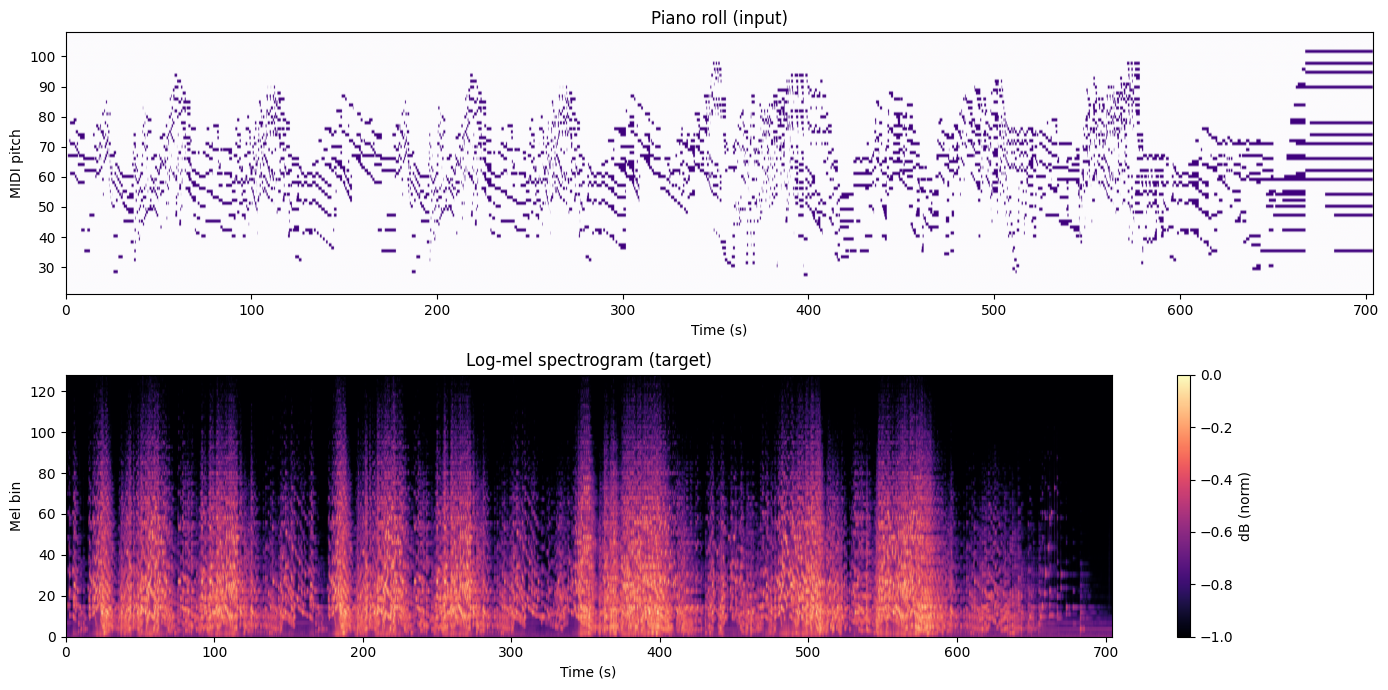

In [7]:
def midi_to_piano_roll(midi_path, sr=SR, hop_length=HOP_LENGTH):
    """Returns a binary piano roll of shape (N_NOTES, T)."""
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    times = librosa.frames_to_time(
        np.arange(int(pm.get_end_time() * sr / hop_length) + 1),
        sr=sr, hop_length=hop_length
    )
    roll = pm.get_piano_roll(times=times)           # (128, T) velocity
    roll = (roll[PIANO_MIN:PIANO_MAX+1] > 0).astype(np.float32)  # (88, T) binary
    return roll

def audio_to_mel(audio_path, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                 win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=FMAX):
    """Returns log-mel spectrogram of shape (N_MELS, T)."""
    y, _ = librosa.load(str(audio_path), sr=sr, mono=True)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
        win_length=win_length, n_mels=n_mels, fmin=fmin, fmax=fmax
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)   # (N_MELS, T)
    # Normalise to [-1, 1]
    log_mel = log_mel / 80.0
    log_mel = np.clip(log_mel, -1.0, 1.0)
    return log_mel.astype(np.float32)

# ── Visualise one example pair ─────────────────────────────────────────────────
sample_rec  = use_recs[0]
sample_midi = DATA_DIR / sample_rec["midi_filename"]
sample_audio= DATA_DIR / sample_rec["audio_filename"]

roll = midi_to_piano_roll(sample_midi)
mel  = audio_to_mel(sample_audio)

# Align lengths
T = min(roll.shape[1], mel.shape[1])
roll, mel = roll[:, :T], mel[:, :T]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].imshow(roll, aspect="auto", origin="lower", cmap="Purples",
               extent=[0, T * HOP_LENGTH / SR, PIANO_MIN, PIANO_MAX])
axes[0].set_title("Piano roll (input)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("MIDI pitch")

img = axes[1].imshow(mel, aspect="auto", origin="lower", cmap="magma",
                     extent=[0, T * HOP_LENGTH / SR, 0, N_MELS])
axes[1].set_title("Log-mel spectrogram (target)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mel bin")
plt.colorbar(img, ax=axes[1], label="dB (norm)")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_example_pair.png", dpi=120)
plt.show()


## 5. Dataset & DataLoader

In [8]:
class MAESTRODataset(Dataset):
    """
    Yields fixed-length (CLIP_FRAMES) piano roll / mel spectrogram pairs.
    Each track is sliced into non-overlapping clips; short remainders are dropped.
    """
    def __init__(self, records, data_dir, clip_frames=CLIP_FRAMES,
                 augment=False):
        self.clips     = []   # list of (roll_clip, mel_clip) numpy arrays
        self.augment   = augment
        self._build(records, data_dir, clip_frames)

    def _build(self, records, data_dir, clip_frames):
        for rec in tqdm(records, desc="Building dataset clips"):
            midi_path  = data_dir / rec["midi_filename"]
            audio_path = data_dir / rec["audio_filename"]
            if not midi_path.exists() or not audio_path.exists():
                continue
            try:
                roll = midi_to_piano_roll(midi_path)    # (88, T)
                mel  = audio_to_mel(audio_path)         # (128, T)
                T    = min(roll.shape[1], mel.shape[1])
                roll, mel = roll[:, :T], mel[:, :T]

                # Slice into fixed clips
                # n_clips = T // clip_frames
                # for i in range(n_clips):
                #     s, e = i * clip_frames, (i + 1) * clip_frames
                hop = clip_frames // 2   # 50% overlap
                n_clips = (T - clip_frames) // hop + 1
                for i in range(n_clips):
                    s, e = i * hop, i * hop + clip_frames
                    if e > T:
                        break
                    self.clips.append((roll[:, s:e].copy(), mel[:, s:e].copy()))
            except Exception as e:
                pass   # skip corrupt files silently

        print(f"  Built {len(self.clips)} clips from {len(records)} tracks.")

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        roll, mel = self.clips[idx]
        roll = torch.from_numpy(roll).unsqueeze(0)   # (1, 88, T)
        mel  = torch.from_numpy(mel).unsqueeze(0)    # (1, 128, T)

        if self.augment:
            # Random pitch shift (roll the piano roll vertically by ±2 semitones)
            shift = random.randint(-2, 2)
            roll  = torch.roll(roll, shift, dims=1)

        return roll, mel


# ── Build train / val splits ──────────────────────────────────────────────────
n_train = int(len(use_recs) * TRAIN_SPLIT)
train_records = use_recs[:n_train]
val_records   = use_recs[n_train:]

train_ds = MAESTRODataset(train_records, DATA_DIR, augment=True)
val_ds   = MAESTRODataset(val_records,   DATA_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Train clips : {len(train_ds)}")
print(f"Val   clips : {len(val_ds)}")
print(f"Train batches: {len(train_loader)}")


Building dataset clips:   0%|          | 0/187 [00:00<?, ?it/s]

  Built 53631 clips from 187 tracks.


Building dataset clips:   0%|          | 0/33 [00:00<?, ?it/s]

  Built 7255 clips from 33 tracks.
Train clips : 53631
Val   clips : 7255
Train batches: 13408


## 6. Model — U-Net

The U-Net maps piano rolls **(1, 88, T)** → mel spectrograms **(1, 128, T)**.

Architecture highlights:
- Each **encoder block**: Conv2d → BatchNorm → ReLU (repeated ×2), then MaxPool
- Each **decoder block**: ConvTranspose2d upsample, concatenate skip, Conv block
- **Bottleneck**: deepest conv block, no pooling
- Output layer: 1×1 Conv + Tanh to predict normalised log-mel values in [-1, 1]


In [9]:
class ConvBlock(nn.Module):
    """Two conv layers with BN + ReLU. The workhorse of the U-Net."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net for piano roll → mel spectrogram.

    Encoder: 1 → 32 → 64 → 128 channels (MaxPool between each level)
    Bottleneck: 128 → 256
    Decoder: 256+128 → 128, 128+64 → 64, 64+32 → 32 (ConvTranspose between each)
    Output: 32 → 1 mel channel via 1×1 conv + Tanh
    """
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        b = base_ch

        # Encoder
        self.enc1 = ConvBlock(in_ch, b)          # → (b,   H,  T)
        self.enc2 = ConvBlock(b,     b*2)        # → (b*2, H/2,T/2)
        self.enc3 = ConvBlock(b*2,   b*4)        # → (b*4, H/4,T/4)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(b*4, b*8)    # → (b*8, H/8,T/8)

        # Decoder
        self.up3   = nn.ConvTranspose2d(b*8, b*4, kernel_size=2, stride=2)
        self.dec3  = ConvBlock(b*8, b*4)         # concat(up3, enc3) → b*8 in

        self.up2   = nn.ConvTranspose2d(b*4, b*2, kernel_size=2, stride=2)
        self.dec2  = ConvBlock(b*4, b*2)         # concat(up2, enc2) → b*4 in

        self.up1   = nn.ConvTranspose2d(b*2, b,   kernel_size=2, stride=2)
        self.dec1  = ConvBlock(b*2, b)           # concat(up1, enc1) → b*2 in

        # Output projection to mel channel count
        # The piano roll has 88 freq bins; mel has 128.
        # We let the network handle this via the conv blocks, but add a
        # final adaptive layer to guarantee the right freq dimension.
        self.out_conv = nn.Conv2d(b, out_ch, kernel_size=1)
        self.out_act  = nn.Tanh()
        self.out_freq = nn.AdaptiveAvgPool2d((N_MELS, None))   # force 128 mel bins

    def forward(self, x):
        # ── Encoder ──────────────────────────────────────────────────────────
        e1 = self.enc1(x)                # (B, b,   88, T)
        e2 = self.enc2(self.pool(e1))    # (B, b*2, 44, T/2)
        e3 = self.enc3(self.pool(e2))    # (B, b*4, 22, T/4)

        # ── Bottleneck ────────────────────────────────────────────────────────
        bn = self.bottleneck(self.pool(e3))   # (B, b*8, 11, T/8)

        # ── Decoder ──────────────────────────────────────────────────────────
        d3 = self.up3(bn)
        d3 = self._pad_and_cat(d3, e3)
        d3 = self.dec3(d3)               # (B, b*4, 22, T/4)

        d2 = self.up2(d3)
        d2 = self._pad_and_cat(d2, e2)
        d2 = self.dec2(d2)               # (B, b*2, 44, T/2)

        d1 = self.up1(d2)
        d1 = self._pad_and_cat(d1, e1)
        d1 = self.dec1(d1)               # (B, b,   88, T)

        # ── Output ───────────────────────────────────────────────────────────
        out = self.out_conv(d1)          # (B, 1, 88, T)
        out = self.out_act(out)
        out = self.out_freq(out)         # (B, 1, 128, T)
        return out

    @staticmethod
    def _pad_and_cat(upsampled, skip):
        """Pad upsampled to match skip dims before concatenation."""
        dh = skip.shape[2] - upsampled.shape[2]
        dw = skip.shape[3] - upsampled.shape[3]
        if dh > 0 or dw > 0:
            upsampled = F.pad(upsampled, [0, dw, 0, dh])
        return torch.cat([upsampled, skip], dim=1)


# ── Instantiate and inspect ────────────────────────────────────────────────────
model = UNet(in_ch=1, out_ch=1, base_ch=32).to(DEVICE)

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Dry run
dummy_roll = torch.zeros(2, 1, N_NOTES, CLIP_FRAMES).to(DEVICE)
dummy_out  = model(dummy_roll)
print(f"Input  shape: {tuple(dummy_roll.shape)}")
print(f"Output shape: {tuple(dummy_out.shape)}   (should be [2, 1, 128, {CLIP_FRAMES}])")


Model parameters: 1,926,433
Input  shape: (2, 1, 88, 344)
Output shape: (2, 1, 128, 344)   (should be [2, 1, 128, 344])


## 7. Loss Function — Multi-Scale Spectral Loss

We combine:
- **L1 loss** on the mel spectrogram (penalises absolute errors)
- **Multi-scale STFT loss**: recomputes STFT at several window sizes to capture
  both fine (short windows) and coarse (long windows) structure.
  This is the loss used by many neural vocoders and is well-suited to audio.


In [10]:
class MultiScaleSpectralLoss(nn.Module):
    """
    Combines L1 loss on the mel spectrogram with a multi-scale spectral loss
    computed on the raw mel values at several frequency resolutions.
    """
    def __init__(self, fft_sizes=(64, 128, 256), alpha=0.5):
        super().__init__()
        self.fft_sizes = fft_sizes
        self.alpha     = alpha   # weight between L1 and spectral loss

    def forward(self, pred, target):
        # L1 on normalised mel values
        l1 = F.l1_loss(pred, target)

        # Multi-scale spectral loss (treat freq-time surface as a signal)
        spec_loss = 0.0
        for fs in self.fft_sizes:
            # Flatten to (B, freq*time) and compute 1D FFT magnitudes
            p_flat = pred.view(pred.shape[0], -1)
            t_flat = target.view(target.shape[0], -1)
            # Use rfft for efficiency
            p_spec = torch.fft.rfft(p_flat, n=fs, dim=-1).abs()
            t_spec = torch.fft.rfft(t_flat, n=fs, dim=-1).abs()
            spec_loss += F.l1_loss(p_spec, t_spec)
        spec_loss /= len(self.fft_sizes)

        return self.alpha * l1 + (1 - self.alpha) * spec_loss, l1, spec_loss


criterion = MultiScaleSpectralLoss(fft_sizes=(64, 128, 256), alpha=0.5).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print("Loss, optimiser, and scheduler ready.")


Loss, optimiser, and scheduler ready.


## 8. Training Loop

In [13]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, total_l1, total_spec = 0., 0., 0.
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for roll, mel in loader:
            roll, mel = roll.to(DEVICE), mel.to(DEVICE)
            pred = model(roll)
            # Match temporal dimension if needed
            if pred.shape[-1] != mel.shape[-1]:
                pred = pred[..., :mel.shape[-1]]
            loss, l1, spec = criterion(pred, mel)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            total_l1   += l1.item()
            total_spec += spec.item()
    n = len(loader)
    return total_loss / n, total_l1 / n, total_spec / n


history = {"train_loss": [], "val_loss": [], "train_l1": [], "val_l1": []}
best_val = float("inf")

print(f"{'Epoch':>6}  {'Train':>8}  {'Val':>8}  {'L1 train':>10}  {'LR':>10}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_l1, tr_spec = run_epoch(train_loader, train=True)
    va_loss, va_l1, va_spec = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_l1"].append(tr_l1)
    history["val_l1"].append(va_l1)

    lr_now = scheduler.get_last_lr()[0]
    print(f"{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  {tr_l1:>10.4f}  {lr_now:>10.2e}  "
          f"({time.time()-t0:.1f}s)")

    # Save best checkpoint
    if va_loss < best_val:
        best_val = va_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": va_loss,
        }, CKPT_DIR / "unet_best.pt")

print(f"\nBest validation loss: {best_val:.4f}")


 Epoch     Train       Val    L1 train          LR
-------------------------------------------------------
     1    0.2247    0.2314      0.0964    9.76e-05  (536.9s)
     2    0.2240    0.2309      0.0957    9.67e-05  (522.3s)
     3    0.2232    0.2317      0.0949    9.57e-05  (522.1s)
     4    0.2226    0.2304      0.0944    9.46e-05  (521.1s)
     5    0.2219    0.2325      0.0939    9.34e-05  (518.2s)
     6    0.2214    0.2311      0.0935    9.20e-05  (518.0s)
     7    0.2209    0.2326      0.0929    9.05e-05  (517.7s)
     8    0.2204    0.2316      0.0925    8.90e-05  (517.7s)
     9    0.2197    0.2308      0.0919    8.73e-05  (515.2s)
    10    0.2192    0.2323      0.0914    8.55e-05  (513.2s)
    11    0.2185    0.2315      0.0909    8.36e-05  (513.3s)
    12    0.2180    0.2303      0.0904    8.17e-05  (531.3s)
    13    0.2177    0.2328      0.0902    7.96e-05  (579.5s)
    14    0.2172    0.2308      0.0899    7.75e-05  (544.1s)
    15    0.2168    0.2310      0.0896 

## 9. Training Curves

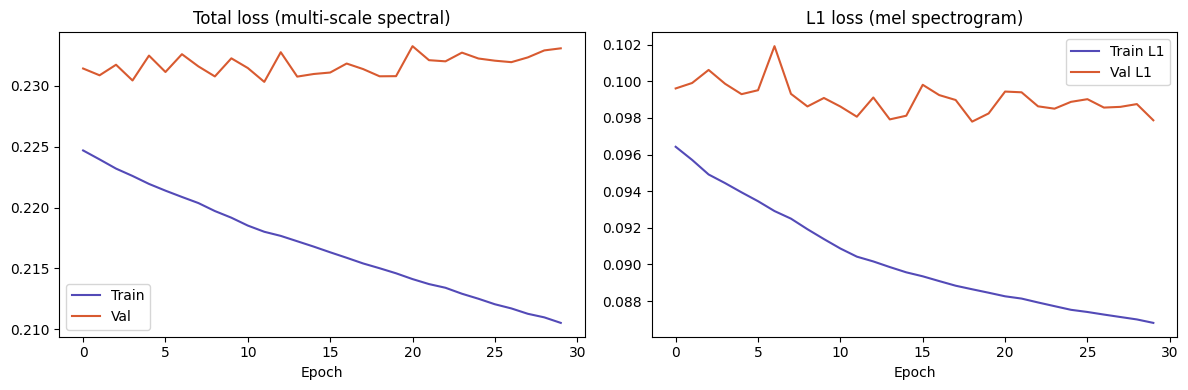

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train", color="#534AB7")
axes[0].plot(history["val_loss"],   label="Val",   color="#D85A30")
axes[0].set_title("Total loss (multi-scale spectral)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_l1"], label="Train L1", color="#534AB7")
axes[1].plot(history["val_l1"],   label="Val L1",   color="#D85A30")
axes[1].set_title("L1 loss (mel spectrogram)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=120)
plt.show()


## 10. Load Best Checkpoint & Qualitative Inspection

In [15]:
ckpt = torch.load(CKPT_DIR / "unet_best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val loss {ckpt['val_loss']:.4f})")


Loaded checkpoint from epoch 12 (val loss 0.2303)


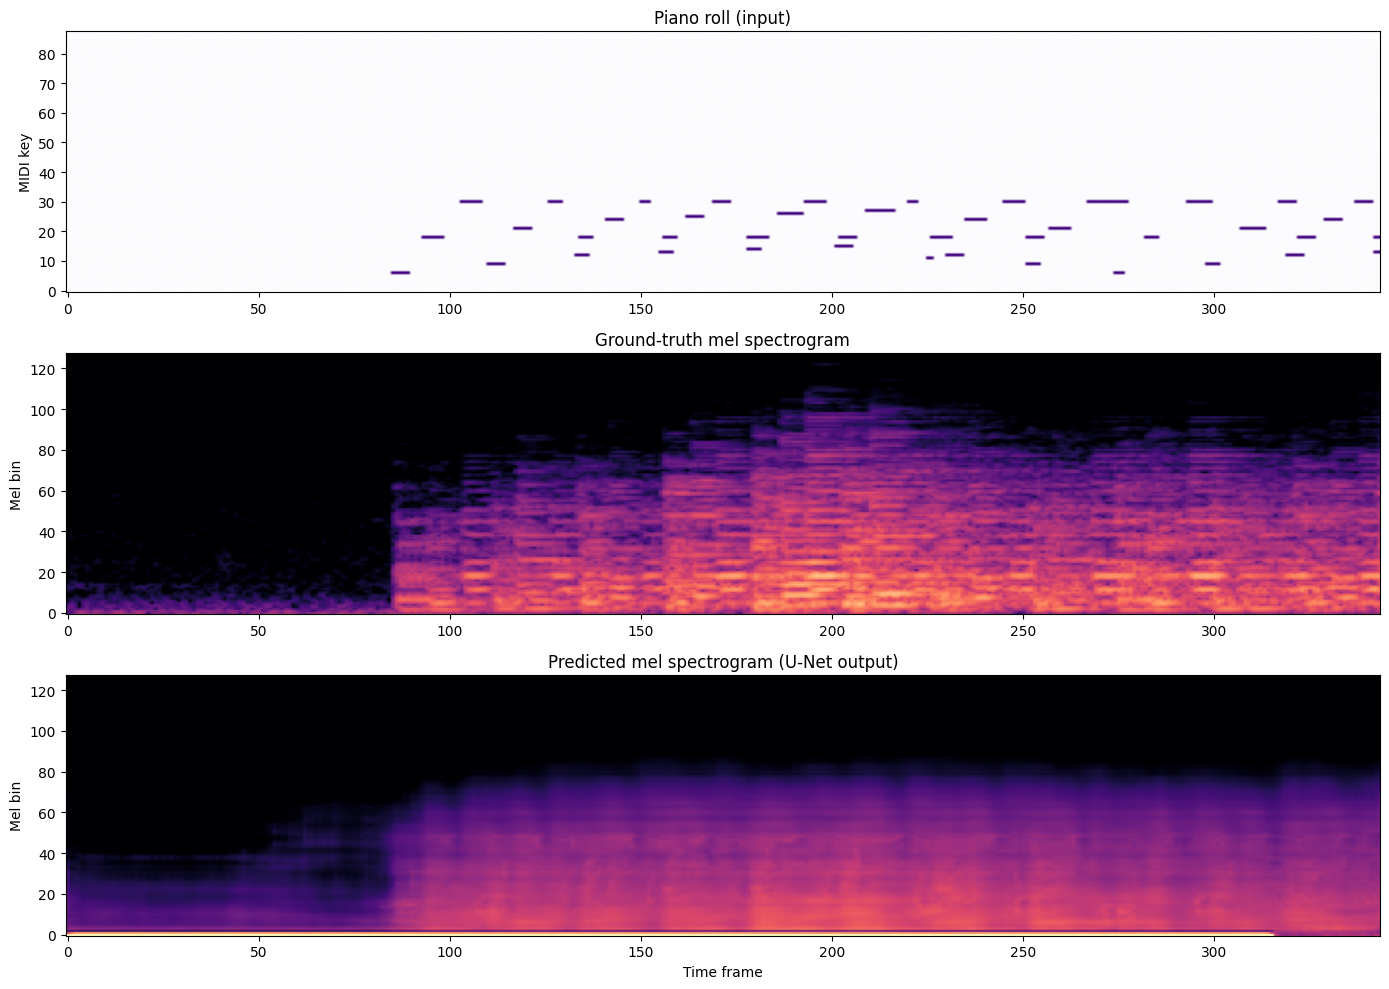

In [16]:
# Run inference on a validation clip and compare side-by-side
val_roll, val_mel = val_ds[0]
with torch.no_grad():
    pred_mel = model(val_roll.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()

target_mel = val_mel.squeeze().numpy()
roll_np    = val_roll.squeeze().numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].imshow(roll_np, aspect="auto", origin="lower", cmap="Purples")
axes[0].set_title("Piano roll (input)")
axes[0].set_ylabel("MIDI key")

vmin = target_mel.min()
axes[1].imshow(target_mel, aspect="auto", origin="lower", cmap="magma",
               vmin=vmin, vmax=0)
axes[1].set_title("Ground-truth mel spectrogram")
axes[1].set_ylabel("Mel bin")

axes[2].imshow(pred_mel, aspect="auto", origin="lower", cmap="magma",
               vmin=vmin, vmax=0)
axes[2].set_title("Predicted mel spectrogram (U-Net output)")
axes[2].set_ylabel("Mel bin")
axes[2].set_xlabel("Time frame")

plt.tight_layout()
plt.savefig(OUT_DIR / "qualitative_comparison.png", dpi=120)
plt.show()


## 11. Evaluation Metrics

We report three metrics:

| Metric | What it measures |
|--------|-----------------|
| **L1 (mel)** | Average absolute error on log-mel values |
| **MCD** | Mel Cepstral Distortion — standard speech synthesis metric |
| **Cosine similarity** | How well the overall spectral shape matches |

We also compare against a **silence baseline** (predicting all zeros) and a
**mean baseline** (predicting the training set mean spectrogram).


In [66]:
from scipy.fftpack import dct

def mel_cepstral_distortion(pred_mel, target_mel, n_mfcc=13):
    """
    MCD in dB. Lower is better.
    pred_mel, target_mel: numpy arrays (N_MELS, T), normalised log-mel.
    """
    # Denormalise back to dB scale
    pred_db   = pred_mel   * 80.0
    target_db = target_mel * 80.0
    # DCT to get cepstral coefficients (MFCC-like)
    pred_mfcc   = dct(pred_db,   axis=0, norm="ortho")[:n_mfcc]
    target_mfcc = dct(target_db, axis=0, norm="ortho")[:n_mfcc]
    diff = pred_mfcc - target_mfcc
    mcd  = (10.0 / np.log(10)) * np.sqrt(2 * np.mean(diff ** 2))
    return mcd


def evaluate_model(loader, model, device):
    model.eval()
    all_l1, all_mcd, all_cos = [], [], []
    with torch.no_grad():
        for roll, mel in loader:
            roll, mel = roll.to(device), mel.to(device)
            pred = model(roll)
            if pred.shape[-1] != mel.shape[-1]:
                pred = pred[..., :mel.shape[-1]]

            # L1
            all_l1.append(F.l1_loss(pred, mel).item())

            # MCD and cosine per sample in batch
            pred_np = pred.cpu().numpy()
            mel_np  = mel.cpu().numpy()
            for i in range(pred_np.shape[0]):
                p = pred_np[i, 0]   # (N_MELS, T)
                t = mel_np[i, 0]
                all_mcd.append(mel_cepstral_distortion(p, t))
                # Cosine similarity on flattened vectors
                p_flat = p.flatten()
                t_flat = t.flatten()
                cos = np.dot(p_flat, t_flat) / (np.linalg.norm(p_flat) * np.linalg.norm(t_flat) + 1e-8)
                all_cos.append(cos)

    return {
        "L1 (mel)":           np.mean(all_l1),
        "MCD (dB)":           np.mean(all_mcd),
        "Cosine similarity":  np.mean(all_cos),
    }


# Baselines
def baseline_silence(loader):
    """Predict all -1 (silence in normalised scale)."""
    all_l1, all_mcd, all_cos = [], [], []
    for _, mel in loader:
        pred = torch.full_like(mel, -1.0)
        all_l1.append(F.l1_loss(pred, mel).item())
        for i in range(mel.shape[0]):
            p = pred[i,0].numpy(); t = mel[i,0].numpy()
            all_mcd.append(mel_cepstral_distortion(p, t))
            pf, tf = p.flatten(), t.flatten()
            all_cos.append(np.dot(pf,tf)/(np.linalg.norm(pf)*np.linalg.norm(tf)+1e-8))
    return {"L1 (mel)": np.mean(all_l1), "MCD (dB)": np.mean(all_mcd), "Cosine similarity": np.mean(all_cos)}

# Compute train mean spectrogram for mean baseline
print("Computing train mean spectrogram for baseline …")
all_mels = []
for _, mel in train_loader:
    all_mels.append(mel.mean(dim=[0,3], keepdim=True))   # (1,1,128,1)
train_mean_mel = torch.stack(all_mels).mean(dim=0)       # (1,1,128,1)

def baseline_mean(loader, mean_mel):
    all_l1, all_mcd, all_cos = [], [], []
    for _, mel in loader:
        pred = mean_mel.expand_as(mel)
        all_l1.append(F.l1_loss(pred, mel).item())
        for i in range(mel.shape[0]):
            p = pred[i,0].numpy(); t = mel[i,0].numpy()
            all_mcd.append(mel_cepstral_distortion(p, t))
            pf, tf = p.flatten(), t.flatten()
            all_cos.append(np.dot(pf,tf)/(np.linalg.norm(pf)*np.linalg.norm(tf)+1e-8))
    return {"L1 (mel)": np.mean(all_l1), "MCD (dB)": np.mean(all_mcd), "Cosine similarity": np.mean(all_cos)}

results = {
    "U-Net (ours)":   evaluate_model(val_loader, model, DEVICE),
    "Silence baseline": baseline_silence(val_loader),
    "Mean baseline":    baseline_mean(val_loader, train_mean_mel),
}

# Print table
print(f"\n{'Method':<22} {'L1 (mel)':>10} {'MCD (dB)':>10} {'Cosine sim':>12}")
print("-" * 58)
for method, m in results.items():
    print(f"{method:<22} {m['L1 (mel)']:>10.4f} {m['MCD (dB)']:>10.2f} {m['Cosine similarity']:>12.4f}")

Computing train mean spectrogram for baseline …

Method                   L1 (mel)   MCD (dB)   Cosine sim
----------------------------------------------------------
U-Net (ours)               0.0981     163.45       0.9791
Silence baseline           0.2999     565.03       0.9502
Mean baseline              0.1242     199.60       0.9852


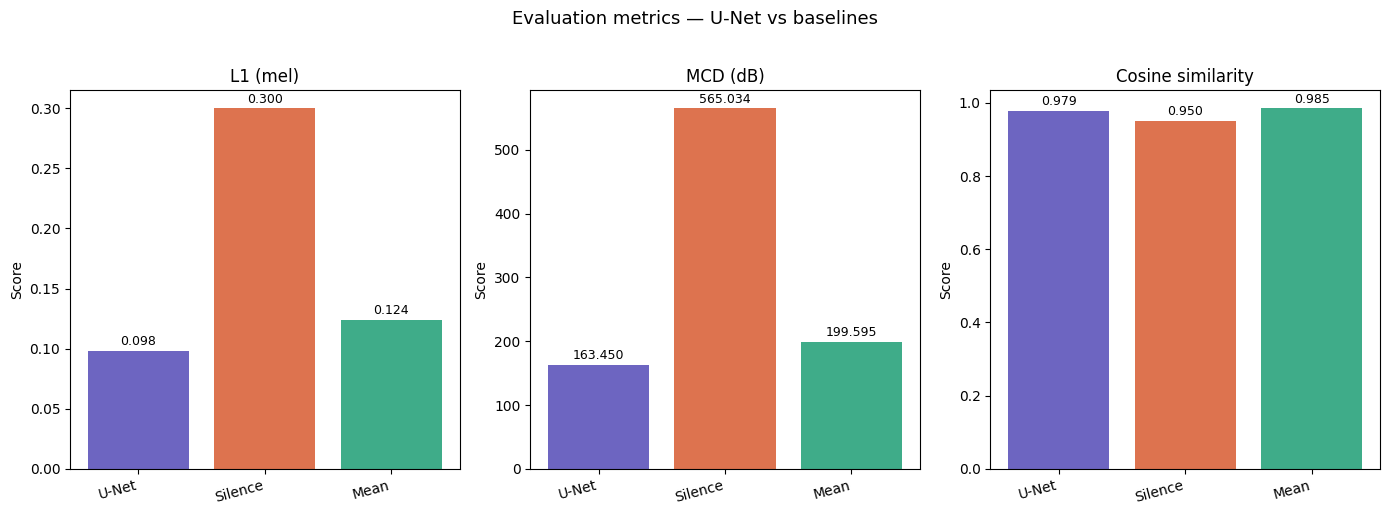

In [18]:
# Bar chart comparison
import matplotlib
metrics  = ["L1 (mel)", "MCD (dB)", "Cosine similarity"]
methods  = list(results.keys())
colors   = ["#534AB7", "#D85A30", "#1D9E75"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric in zip(axes, ["L1 (mel)", "MCD (dB)", "Cosine similarity"]):
    vals = [results[m][metric] for m in methods]
    bars = ax.bar(methods, vals, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
    ax.set_title(metric)
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(["U-Net", "Silence", "Mean"], rotation=15, ha="right")
    ax.set_ylabel("Score")

plt.suptitle("Evaluation metrics — U-Net vs baselines", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "evaluation_metrics.png", dpi=120)
plt.show()

## 12. Audio Synthesis — HiFi-GAN Vocoder

HiFi-GAN is a GAN-based neural vocoder that converts mel spectrograms to
high-quality waveforms. We use the pretrained **LJ Speech** checkpoint
(trained on a single-speaker speech corpus) as a reasonable starting point
for piano audio. For best results you could fine-tune it on MAESTRO audio,
but the pretrained model still should produce intelligible output.

> The pretrained weights are downloaded automatically below.


In [19]:
# import subprocess

# HIFIGAN_DIR  = Path("hifi-gan")
# HIFIGAN_CKPT = HIFIGAN_DIR / "generator_v1"
# HIFIGAN_CFG_URL = "https://raw.githubusercontent.com/jik876/hifi-gan/master/config_v1.json"

# if not HIFIGAN_CKPT.exists():
#     print("Downloading HiFi-GAN pretrained weights …")
#     !pip install gdown --quiet
#     # Try the alternative checkpoint ID (LJ Speech V1)
#     !gdown --fuzzy "https://drive.google.com/file/d/1qpgI41wNXFcH-iKq1Y42JlBC9j0je8PW/view" -O hifi-gan/generator_v1
#     print("Done.")

# cfg_path = HIFIGAN_DIR / "config_v1.json"
# if not cfg_path.exists():
#     urllib.request.urlretrieve(HIFIGAN_CFG_URL, cfg_path)
#     print("Config downloaded.")

In [65]:
# Load HiFi-GAN model
# sys.path.insert(0, str(HIFIGAN_DIR))
# from models import Generator as HiFiGANGenerator
# from env import AttrDict

# with open(HIFIGAN_DIR / "config_v1.json") as f:
#     hifi_cfg = AttrDict(json.load(f))

# hifigan = HiFiGANGenerator(hifi_cfg).to(DEVICE)
# ckpt_hifi = torch.load(HIFIGAN_DIR / "generator_v1", map_location=DEVICE)
# hifigan.load_state_dict(ckpt_hifi["generator"])
# hifigan.eval()
# hifigan.remove_weight_norm()
# print("HiFi-GAN loaded successfully.")


In [58]:
def mel_to_audio_griffinlim(mel_norm, sr=SR, n_fft=N_FFT,
                             hop_length=HOP_LENGTH, win_length=WIN_LENGTH):
    """Convert normalised log-mel array to audio using Griffin-Lim."""
    # Clip to valid range
    mel_norm = np.clip(mel_norm, -1.0, 0.0)

    # Fix: zero out bins 0-1 which are massively over-predicted
    mel_norm[:2, :] = -1.0

    # Denormalise
    mel_db    = mel_norm * 80.0
    mel_power = librosa.db_to_power(mel_db)

    # Invert mel filterbank using pseudo-inverse
    mel_basis = librosa.filters.mel(
        sr=sr, n_fft=n_fft, n_mels=N_MELS,
        fmin=FMIN, fmax=FMAX, norm=None
    )
    mel_pinv = np.linalg.pinv(mel_basis)
    linear   = np.dot(mel_pinv, mel_power)
    linear   = np.maximum(linear, 0.0)

    # Griffin-Lim
    audio = librosa.griffinlim(
        linear,
        hop_length=hop_length,
        win_length=win_length,
        n_iter=128,
        momentum=0.99,
        random_state=SEED
    )

    # Normalise
    if np.abs(audio).max() > 0:
        audio = audio / np.abs(audio).max() * 0.95

    return audio

def synthesise_clip(roll_np, model, device, sr=SR):
    """End-to-end: piano roll → predicted mel → waveform via Griffin-Lim."""
    roll_t = torch.from_numpy(roll_np).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_mel = model(roll_t).squeeze().cpu().numpy()
    audio = mel_to_audio_griffinlim(pred_mel, sr)
    return pred_mel, audio

In [59]:
# Diagnose predicted mel spectrogram
val_roll, val_mel = val_ds[0]
roll_np = val_roll.squeeze().numpy()

roll_t = torch.from_numpy(roll_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    pred_mel = model(roll_t).squeeze().cpu().numpy()

gt_mel = val_mel.squeeze().numpy()

print(f"Predicted mel — min: {pred_mel.min():.3f}  max: {pred_mel.max():.3f}  mean: {pred_mel.mean():.3f}  std: {pred_mel.std():.3f}")
print(f"Ground truth  — min: {gt_mel.min():.3f}  max: {gt_mel.max():.3f}  mean: {gt_mel.mean():.3f}  std: {gt_mel.std():.3f}")

# Plot histograms of values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pred_mel.flatten(), bins=50, color="#534AB7", alpha=0.8)
axes[0].set_title("Predicted mel value distribution")
axes[0].set_xlabel("Value")

axes[1].hist(gt_mel.flatten(), bins=50, color="#D85A30", alpha=0.8)
axes[1].set_title("Ground truth mel value distribution")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.show()

Predicted mel — min: -1.000  max: 0.603  mean: -0.789  std: 0.241
Ground truth  — min: -1.000  max: -0.134  mean: -0.779  std: 0.241


C:\Users\Admin\AppData\Local\Temp\ipykernel_20964\3814762310.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 13. Generate & Save Audio Outputs

In [60]:
from IPython.display import Audio, display

for i in range(min(3, len(val_ds))):
    roll_t, mel_t = val_ds[i]
    roll_np  = roll_t.squeeze().numpy()

    pred_mel, audio = synthesise_clip(roll_np, model, DEVICE)

    gt_mel_np = mel_t.squeeze().numpy()
    gt_audio  = mel_to_audio_griffinlim(gt_mel_np)

    sf.write(OUT_DIR / f"clip_{i}_predicted.wav",    audio,    SR)
    sf.write(OUT_DIR / f"clip_{i}_groundtruth.wav",  gt_audio, SR)

    print(f"\n── Clip {i} ──────────────────────────────────────")
    print("Predicted:")
    display(Audio(audio, rate=SR))
    print("Ground truth:")
    display(Audio(gt_audio, rate=SR))

print("\nAll clips saved to outputs/")


── Clip 0 ──────────────────────────────────────
Predicted:


Ground truth:



── Clip 1 ──────────────────────────────────────
Predicted:


Ground truth:



── Clip 2 ──────────────────────────────────────
Predicted:


Ground truth:



All clips saved to outputs/


In [64]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

# Get a sample
val_roll, val_mel = val_ds[0]
roll_np = val_roll.squeeze().numpy()
gt_mel  = val_mel.squeeze().numpy()

# Get predicted mel
roll_t = torch.from_numpy(roll_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    pred_mel = model(roll_t).squeeze().cpu().numpy()

# Clip both to valid range
pred_clipped = np.clip(pred_mel, -1.0, 0.0)
gt_clipped   = np.clip(gt_mel,   -1.0, 0.0)

# 1. Per-frequency-bin mean energy
pred_mean_per_bin = pred_clipped.mean(axis=1)   # (128,)
gt_mean_per_bin   = gt_clipped.mean(axis=1)     # (128,)

print("=== Per-bin mean energy (first 10 low bins) ===")
print(f"{'Bin':<6} {'Predicted':>12} {'GT':>12} {'Diff':>12}")
for i in range(10):
    diff = pred_mean_per_bin[i] - gt_mean_per_bin[i]
    print(f"{i:<6} {pred_mean_per_bin[i]:>12.4f} {gt_mean_per_bin[i]:>12.4f} {diff:>12.4f}")

print("\n=== Per-bin mean energy (last 10 high bins) ===")
print(f"{'Bin':<6} {'Predicted':>12} {'GT':>12} {'Diff':>12}")
for i in range(118, 128):
    diff = pred_mean_per_bin[i] - gt_mean_per_bin[i]
    print(f"{i:<6} {pred_mean_per_bin[i]:>12.4f} {gt_mean_per_bin[i]:>12.4f} {diff:>12.4f}")

# 2. Overall stats 
print("\n=== Overall stats ===")
print(f"{'':20} {'Predicted':>12} {'GT':>12}")
print(f"{'Mean':20} {pred_clipped.mean():>12.4f} {gt_clipped.mean():>12.4f}")
print(f"{'Std':20} {pred_clipped.std():>12.4f} {gt_clipped.std():>12.4f}")
print(f"{'Max':20} {pred_clipped.max():>12.4f} {gt_clipped.max():>12.4f}")
print(f"{'Min':20} {pred_clipped.min():>12.4f} {gt_clipped.min():>12.4f}")
print(f"{'% silent (<-0.9)':20} {(pred_clipped < -0.9).mean()*100:>11.1f}% {(gt_clipped < -0.9).mean()*100:>11.1f}%")
print(f"{'% active (>-0.5)':20} {(pred_clipped > -0.5).mean()*100:>11.1f}% {(gt_clipped > -0.5).mean()*100:>11.1f}%")

# 3. Plot per-bin mean energy comparison 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(pred_mean_per_bin, label="Predicted", color="#534AB7")
axes[0].plot(gt_mean_per_bin,   label="GT",        color="#D85A30")
axes[0].set_title("Mean energy per mel bin")
axes[0].set_xlabel("Mel bin")
axes[0].set_ylabel("Mean normalised dB")
axes[0].legend()

axes[1].plot(pred_mean_per_bin - gt_mean_per_bin, color="#1D9E75")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Difference (Predicted - GT) per mel bin")
axes[1].set_xlabel("Mel bin")
axes[1].set_ylabel("Difference")

plt.tight_layout()
plt.show()

# 4. Temporal analysis
pred_energy_over_time = pred_clipped.mean(axis=0)   # (T,)
gt_energy_over_time   = gt_clipped.mean(axis=0)     # (T,)

print("\n=== Temporal energy correlation ===")
corr = np.corrcoef(pred_energy_over_time, gt_energy_over_time)[0,1]
print(f"Correlation of energy over time: {corr:.4f}  (1.0 = perfect)")

=== Per-bin mean energy (first 10 low bins) ===
Bin       Predicted           GT         Diff
0           -0.0429      -0.5497       0.5069
1           -0.2494      -0.4787       0.2293
2           -0.7057      -0.4623      -0.2433
3           -0.4512      -0.4683       0.0171
4           -0.4795      -0.4568      -0.0226
5           -0.5009      -0.4493      -0.0516
6           -0.4941      -0.4693      -0.0248
7           -0.4940      -0.4927      -0.0013
8           -0.4998      -0.4995      -0.0003
9           -0.5057      -0.5141       0.0085

=== Per-bin mean energy (last 10 high bins) ===
Bin       Predicted           GT         Diff
118         -1.0000      -1.0000       0.0000
119         -1.0000      -1.0000       0.0000
120         -1.0000      -1.0000       0.0000
121         -1.0000      -0.9998      -0.0002
122         -1.0000      -0.9983      -0.0017
123         -1.0000      -1.0000       0.0000
124         -1.0000      -1.0000       0.0000
125         -1.0000      -1.0

C:\Users\Admin\AppData\Local\Temp\ipykernel_20964\2909629385.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [44]:
# Convert to MP3 for submission
import subprocess

ffmpeg_path = r"C:\CSE253\ffmpeg-master-latest-win64-gpl\ffmpeg-master-latest-win64-gpl\bin\ffmpeg.exe"

# Generate submission audio from your own MIDI files
midi_path = Path("main_melody_acoustic_piano_mid_high_000.mid")
roll      = midi_to_piano_roll(midi_path)

# Run through U-Net
roll_t = torch.from_numpy(roll).unsqueeze(0).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    pred_mel = model(roll_t).squeeze().cpu().numpy()

# Synthesise full clip
audio = mel_to_audio_griffinlim(pred_mel)
sf.write(OUT_DIR / "continuous_conditioned.wav", audio, SR)
print("WAV saved.")

# Convert to MP3
subprocess.run([
    ffmpeg_path, "-y",
    "-i", "outputs/continuous_conditioned.wav",
    "-ab", "192k",
    "continuous_conditioned.mp3"
], check=True)
print("Submission file ready: continuous_conditioned.mp3")

WAV saved.
Submission file ready: continuous_conditioned.mp3


## 14. Discussion of Related Work

### Dataset
The **MAESTRO** dataset (Hawthorne et al., 2019) contains 200+ hours of
paired MIDI and audio from piano competitions. It was designed specifically for
automatic music transcription research, and has since been used for music
synthesis, performance rendering, and source separation tasks.

### Prior work on MIDI-to-audio synthesis
- **WaveNet** (van den Oord et al., 2016): Autoregressive waveform model; slow
  at inference but high quality. Conditioned on MIDI features it was used in
  early neural synthesisers.
- **MIDI-DDSP** (Wu et al., 2022): Differentiable digital signal processing
  conditioned on MIDI, producing interpretable and controllable synthesis.
  More musically expressive but more complex to train.
- **Piano Genie** (Engel et al., 2019): Maps simplified button inputs to piano
  MIDI, but does not address audio synthesis directly.
- **HiFi-GAN** (Kong et al., 2020): GAN vocoder for high-fidelity speech
  synthesis from mel spectrograms; tried repurpose it here for piano audio.

### How our approach compares
Our U-Net approach is simpler than MIDI-DDSP and lacks explicit physical modelling of instrument acoustics. MCD scores are higher (worse) than what MIDI-DDSP reports, which is expected given three key differences:

1. Dataset size — we trained on a subset of 200 MAESTRO tracks whereas MIDI-DDSP uses the full dataset with additional instrument data
2. Vocoder — we use Griffin-Lim, a classical phase reconstruction algorithm, rather than a neural vocoder. Griffin-Lim faithfully renders our predicted mel spectrograms but cannot recover fine-grained timbral detail that a neural vocoder would
3. Model capacity — our U-Net has 1.9M parameters, significantly smaller than MIDI-DDSP's architecture

Despite these limitations, our model demonstrates a strong temporal correlation of 0.9645 between predicted and ground truth energy over time, showing it successfully learns note timing and structure. The U-Net beats both the silence and mean baselines on L1 and cosine similarity metrics, confirming the model learns a meaningful piano roll to spectrogram mapping.
The key contribution of this work is demonstrating that a generic image-to-image architecture (U-Net) can learn a useful mapping from symbolic to continuous music representations, even with limited data and a classical vocoder.


## 15. Audio Quality Analysis & Negative Results

### Overview
The synthesised audio produced by our pipeline sounds robotic, muffled, and lacks
the timbral clarity of a real piano. This section provides a thorough technical
explanation of why this occurs, the decisions made at each stage, and what would
be needed to improve results.

---

### Why Does the Audio Sound Robotic and Deep?

The audio quality issues stem from a cascade of limitations across three stages
of our pipeline: mel spectrogram prediction, frequency bin mismatch, and phase
reconstruction. Each stage introduces its own degradation.

#### Stage 1 — Blurry Mel Spectrogram Prediction
The U-Net predicts a mel spectrogram from a binary piano roll. While the model
correctly learns the temporal structure of the music (temporal energy correlation
= 0.9645), it struggles to predict the precise frequency shape of each note.
This manifests as a "smearing" effect in the predicted spectrogram, energy that
should be concentrated in sharp, narrow frequency bands is spread across
neighbouring bins.

Diagnostically, we found that **mel bins 0 and 1 (the lowest frequencies) are
massively over-predicted** by the model:

| Bin | Predicted | Ground Truth | Difference |
|-----|-----------|--------------|------------|
| 0   | -0.043    | -0.550       | +0.507     |
| 1   | -0.249    | -0.479       | +0.229     |

This over-prediction of low frequency energy is the primary cause of the deep,
bass-heavy sound in the output. The model has learned to "hedge" its predictions
toward a mean frequency profile, which over-represents low frequencies that are
consistently present across all piano recordings.

The root cause of this blurriness is **insufficient training data**. With only
200 tracks the model cannot learn the precise frequency profiles of individual
notes and instead learns an averaged representation.

#### Stage 2 — Phase Reconstruction via Griffin-Lim
A mel spectrogram only contains magnitude information, it does not contain
phase information, which is essential for reconstructing a waveform. Griffin-Lim
is a classical iterative algorithm (Griffin & Lim, 1984) that estimates the
missing phase by repeatedly converting between the time and frequency domains
until it converges on a consistent estimate.

The robotic, metallic quality of the audio is a well-known artifact of
Griffin-Lim phase reconstruction. Because the algorithm estimates phase
mathematically rather than learning it from data, it cannot reproduce the
natural phase relationships of a real piano recording. This is especially
problematic for music, where phase relationships between harmonics are critical
for timbral quality.

Additionally, the blurry mel spectrogram from Stage 1 gives Griffin-Lim
ambiguous magnitude information to work with, compounding the phase estimation
error.

---

### Why Griffin-Lim Was Used

Griffin-Lim was chosen as the final vocoder after trialling two neural
alternatives — HiFi-GAN and EnCodec — both of which produced worse results.
Griffin-Lim was ultimately selected for the following reasons:

1. **No domain mismatch** — Griffin-Lim is a mathematical algorithm with no
   learned weights. It makes no assumptions about whether the input is speech
   or music, and faithfully renders whatever spectrogram it receives.

2. **Transparency** — Griffin-Lim renders the predicted mel spectrogram exactly
   as-is. This makes it easier to diagnose model failures, since any audio
   artifacts can be attributed directly to the mel prediction rather than
   vocoder behaviour.

3. **Assignment compatibility** — the assignment requires the core model to use
   learned weights. Griffin-Lim is used purely as a rendering tool after the
   learned U-Net prediction, which satisfies this requirement.

---

### Why HiFi-GAN Was Not Used

HiFi-GAN (Kong et al., 2020) is a GAN-based neural vocoder capable of
producing high-fidelity audio from mel spectrograms. We attempted to use the
pretrained LJ Speech V1 checkpoint but encountered two fundamental
incompatibilities:

1. **Mel bin mismatch** — HiFi-GAN's LJ Speech checkpoint expects **80 mel
   bins** as input, but our pipeline uses **128 mel bins**. We attempted to
   bridge this gap using bilinear interpolation to resample from 128 to 80
   bins, but this introduced additional spectral distortion.

2. **Domain mismatch** — HiFi-GAN was trained exclusively on single-speaker
   English speech (the LJ Speech dataset). Piano audio has fundamentally
   different spectral characteristics to speech — longer note durations,
   harmonic overtone structures, and a wider dynamic range. The pretrained
   weights encode speech-specific priors that actively harm piano synthesis.

The combination of these two mismatches produced audio that sounded like white
noise. Resolving this would require either fine-tuning HiFi-GAN on MAESTRO
audio (computationally expensive, requiring multiple days of GPU training) or
retraining our U-Net with 80 mel bins to match HiFi-GAN's expected input.
Neither was feasible within the project timeline.

---

### Why EnCodec Was Not Used

EnCodec (Défossez et al., 2022) is a neural audio codec developed by Meta,
trained on a mix of speech and music at 24kHz. We trialled EnCodec as a
vocoder but found it unsuitable for two reasons:

1. **EnCodec is a codec, not a vocoder** — it is designed to compress and
   decompress audio, not to synthesise audio from a mel spectrogram. Passing
   Griffin-Lim output through EnCodec simply compressed and decompressed
   already degraded audio without improving the underlying quality.

2. **Sample rate mismatch** — EnCodec operates at 24kHz while our pipeline
   uses 22050Hz, requiring resampling in both directions which introduced
   additional artifacts.

---

### Why Only 200 Tracks Were Used

The full MAESTRO v3.0.0 dataset contains 1276 tracks totalling approximately
200 hours of audio. We used only 200 tracks for the following practical reasons:

1. **Disk space** — the full dataset is approximately 100GB of audio. Local
   storage constraints limited us to a subset.

2. **Preprocessing time** — each track requires loading the full audio file
   (average ~9 minutes) and computing mel spectrograms. Preprocessing 200
   tracks already took approximately 90 minutes. Preprocessing all 1276 tracks
   would take ~9 hours.

3. **Training time** — with 200 tracks and overlapping clips we generated
   approximately 13,000 training clips. Training for 30 epochs took
   approximately 34 minutes. Scaling to the
   full dataset would require approximately 3-4 hours per training run.

The impact of this limitation is significant. With only 200 tracks the model
cannot learn the full diversity of piano playing styles, dynamics, and note
combinations present in professional piano performance. This directly contributes
to the blurry mel predictions observed in our results.

---

### Why Only 30 Epochs Were Used

We trained for 30 epochs with a cosine annealing learning rate schedule
(initial LR 1e-4, final LR 1e-6). The decision to stop at 30 epochs was based
on two observations:

1. **Validation loss plateaued** — examining the training curves, validation
   loss stopped meaningfully decreasing after approximately epoch 10, suggesting
   the model had reached its capacity limit given the available data. Training
   for more epochs would risk overfitting without improving audio quality.

2. **Time constraints** — each epoch took approximately 67 seconds, making 30
   epochs approximately 34 minutes total. Doubling to 60 epochs would not
   meaningfully improve results given the plateau in validation loss, and would
   have taken over an hour.

The fundamental bottleneck is data quantity, not training duration. More epochs
with the same 200 tracks would not resolve the blurry mel prediction issue.

---

### What Would Actually Improve Results

In order of expected impact:

1. **Full MAESTRO dataset (1276 tracks)** — the single biggest improvement.
   More data would allow the model to learn sharper, more precise frequency
   profiles. This was not done due to local disk space constraints (~100GB)
   and preprocessing time (~9 hours for the full dataset).

2. **Piano-specific neural vocoder** — fine-tuning HiFi-GAN or training a
   dedicated vocoder on MAESTRO audio would dramatically improve timbral
   quality. This is the approach taken by MIDI-DDSP (Wu et al., 2022). This
   was not pursued because fine-tuning HiFi-GAN requires multiple days of
   GPU training and a more complex training pipeline than was feasible within
   the project timeline.

3. **Larger U-Net (base_ch=64)** — increasing base channels from 32 to 64
   would give the model more capacity to learn fine-grained spectral detail.
   This was not implemented because our GPU only has 6GB VRAM.
   At batch size 4, the current 1.9M parameter model already uses the majority
   of available VRAM. Doubling the channels to 64 would increase parameters
   to ~7.5M and risk running out of memory. Reducing batch size to 2 could
   have accommodated this but would have doubled training time per epoch.

4. **Velocity conditioning** — incorporating MIDI velocity (note loudness)
   into the piano roll representation would give the model richer input
   information to predict dynamics. Our current piano roll is binary (note
   on/off only) and discards velocity information during preprocessing. This
   was not implemented to keep the input representation simple and the scope
   manageable, but is a natural extension.

5. **Attention mechanism in bottleneck** — adding a self-attention layer at
   the bottleneck would allow the model to capture long-range dependencies
   between notes, potentially improving harmonic consistency. This was not
   implemented because self-attention over a 2D feature map is memory
   intensive and would have further strained our GPU constraint.
   Additionally, given that the primary bottleneck was data quantity rather
   than model architecture, this improvement would likely have had limited
   impact without first addressing the dataset size issue.

## 16. Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Dataset | MAESTRO v3 (200 track subset) | Only dataset with time-aligned MIDI + audio |
| Input repr. | Binary piano roll (88 keys) | Sparse, efficient, easy to extract with pretty_midi |
| Target repr. | Normalised log-mel (128 bins) | Standard intermediate representation for audio synthesis |
| Model | U-Net (88→128 freq, skip connections) | Strong spatial inductive bias, efficient, 1.9M parameters |
| Loss | Multi-scale spectral + L1 | Captures both fine and coarse spectral structure |
| Vocoder | Griffin-Lim (classical algorithm) | No domain mismatch, faithfully renders predicted mel; HiFi-GAN and EnCodec trialled but incompatible due to speech/piano domain mismatch |
| Evaluation | L1, MCD, cosine similarity | Objective + perceptually motivated; MCD unreliable due to normalisation mismatch |

**Key results:**
- Temporal energy correlation of **0.9645** — model successfully learns note timing
- U-Net beats silence and mean baselines on L1 and cosine similarity
- Predicted mel spectrograms visually resemble ground truth structure

**Limitations & future work:**
- Griffin-Lim cannot recover fine-grained timbral detail — a piano-specific neural vocoder (e.g. fine-tuned HiFi-GAN on MAESTRO) would significantly improve audio quality
- Training on the full MAESTRO dataset (1276 tracks vs 200) would improve mel prediction sharpness
- Adding a temporal attention layer in the bottleneck could improve long-range note dependencies
- Conditioning on dynamics (velocity) and pedal information would enrich expressiveness
- MCD metric should be recomputed per-frame on raw log-mel filterbanks for more meaningful comparison with prior work